## Config

In [56]:
# Global config (edit as needed)
TICKERS = [
            "ABB.NS", "ADANIENT.NS", "ADANIPOWER.NS", "AMBUJACEM.NS", "APOLLOHOSP.NS",
            "ASIANPAINT.NS", "AXISBANK.NS", "BAJAJ-AUTO.NS", "BAJFINANCE.NS", "BAJAJFINSV.NS",
            "BPCL.NS", "BHARTIARTL.NS", "BHEL.NS", "BEL.NS", "BANKBARODA.NS",
            "BOSCHLTD.NS", "BRITANNIA.NS", "ZYDUSLIFE.NS", "CANBK.NS", "CHOLAFIN.NS",
            "CIPLA.NS", "COALINDIA.NS", "DABUR.NS", "DIVISLAB.NS", "DLF.NS",
            "DRREDDY.NS", "EICHERMOT.NS", "GAIL.NS", "GODREJCP.NS", "GRASIM.NS",
            "HAVELLS.NS", "HCLTECH.NS", "HDFCBANK.NS", "HEROMOTOCO.NS", "HINDALCO.NS",
            "HINDUNILVR.NS", "IOC.NS", "ICICIBANK.NS", "INDUSINDBK.NS", "NAUKRI.NS",
            "INFY.NS", "ITC.NS", "JSWSTEEL.NS", "JINDALSTEL.NS", "JSWENERGY.NS",
            "KOTAKBANK.NS", "LT.NS", "M&M.NS", "MARUTI.NS", "MOTHERSON.NS",
            "ADANIPORTS.NS", "NTPC.NS", "NHPC.NS", "ONGC.NS", "PIDILITIND.NS",
            "PFC.NS", "POWERGRID.NS", "PNB.NS", "RELIANCE.NS", "RECLTD.NS",
            "SBIN.NS", "VEDL.NS", "SHREECEM.NS", "SHRIRAMFIN.NS", "SIEMENS.NS",
            "SUNPHARMA.NS", "TCS.NS", "TATACONSUM.NS", "TATAMOTORS.NS", "TATAPOWER.NS",
            "TATASTEEL.NS", "TECHM.NS", "TITAN.NS", "TORNTPHARM.NS", "TRENT.NS",
            "TVSMOTOR.NS", "ULTRACEMCO.NS", "UNIONBANK.NS", "MCDOWELL-N.NS", "WIPRO.NS",
            "NESTLEIND.NS", "ADANIENSOL.NS", "INDIGO.NS", "LTIM.NS", "ICICIPRULI.NS",
            "VBL.NS", "DMART.NS", "ICICIGI.NS", "SBILIFE.NS", "HDFCLIFE.NS",
            "HAL.NS", "ADANIGREEN.NS", "ADANITOTAL.NS", "IRCTC.NS", "IRFC.NS",
            "LODHA.NS", "ECLERX.NS", "LICIndia.NS", "JIOFIN.NS"
]
START = "2018-01-01"
TEST_WEEKS = 20
COST_BPS = 10
ALLOW_SHORT = 0            # set to 1 to enable shorting
TOTAL_TIMESTEPS = 200_000  # reduce if training is slow

import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (8,4)

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE


'cpu'

## metrics

In [57]:
import numpy as np

def sharpe_ratio(returns, rf=0.0, periods=252):
    r = np.asarray(returns); 
    if len(r)==0 or r.std()==0: return 0.0
    ann_ret = (1 + r.mean())**periods - 1
    ann_vol = r.std() * np.sqrt(periods)
    return float((ann_ret - rf) / (ann_vol + 1e-12))

def sortino_ratio(returns, rf=0.0, periods=252):
    r = np.asarray(returns); 
    if len(r)==0: return 0.0
    downside = np.std(np.minimum(0, r))
    if downside==0: return 0.0
    ann_ret = (1 + r.mean())**periods - 1
    ann_down = downside * np.sqrt(periods)
    return float((ann_ret - rf) / (ann_down + 1e-12))

def max_drawdown(cum_curve):
    curve = np.asarray(cum_curve); 
    if len(curve)==0: return 0.0
    peak = np.maximum.accumulate(curve)
    dd = (curve - peak) / (peak + 1e-12)
    return float(dd.min())

def cagr(returns, periods=252):
    r = np.asarray(returns); 
    if len(r)==0: return 0.0
    cum = (1 + r).prod()
    years = len(r) / periods
    if years <= 0: return 0.0
    return float(cum ** (1/years) - 1)

def hit_rate(returns):
    r = np.asarray(returns)
    return float((r > 0).mean()) if len(r) else 0.0

def turnover(positions):
    p = np.asarray(positions); 
    if len(p)<2: return 0.0
    return float(np.abs(np.diff(p)).sum() / (len(p) - 1))


## features

In [58]:
import pandas as pd
import numpy as np

def rsi(series, window=14):
    delta = series.diff()
    up = delta.clip(lower=0.0)
    down = -delta.clip(upper=0.0)
    roll_up = up.ewm(alpha=1/window, adjust=False).mean()
    roll_down = down.ewm(alpha=1/window, adjust=False).mean()
    rs = roll_up / (roll_down + 1e-12)
    return 100 - (100 / (1 + rs))

def macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    hist = macd_line - signal_line
    return macd_line, signal_line, hist

def atr(high, low, close, window=14):
    prev_close = close.shift(1)
    tr = pd.concat([high - low, (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)
    return tr.rolling(window).mean()

def make_features(df, use_additional=True):
    out = pd.DataFrame(index=df.index.copy())
    out['close'] = df['Close']
    out['open'] = df['Open']
    out['volume'] = df['Volume']

    # 10 lag returns
    out['ret1'] = df['Close'].pct_change()
    for k in range(2, 11):
        out[f'ret{k}'] = df['Close'].pct_change(k)

    # MAs
    out['ma5'] = df['Close'].rolling(5).mean()
    out['ma20'] = df['Close'].rolling(20).mean()
    out['ma5_ma20_diff'] = out['ma5'] - out['ma20']
    out['ma5_ma20_ratio'] = out['ma5'] / (out['ma20'] + 1e-12)

    # RSI & MACD
    out['rsi14'] = rsi(df['Close'], 14)
    macd_line, signal_line, hist = macd(df['Close'], 12, 26, 9)
    out['macd'] = macd_line
    out['macd_signal'] = signal_line
    out['macd_hist'] = hist

    # Volume regime, gaps, intraday
    out['vol_z'] = (df['Volume'] - df['Volume'].rolling(20).mean()) / (df['Volume'].rolling(20).std() + 1e-12)
    out['overnight_gap'] = (df['Open'] / df['Close'].shift(1) - 1)
    out['intraday_ret'] = (df['Close'] / df['Open'] - 1)

    # Volatility & ATR
    out['rv10'] = df['Close'].pct_change().rolling(10).std()
    out['rv20'] = df['Close'].pct_change().rolling(20).std()
    out['atr14'] = atr(df['High'], df['Low'], df['Close'], 14)

    # Day-of-week dummies (Mon..Fri)
    dow = pd.Series(df.index.dayofweek, index=df.index)
    for i in range(5):
        out[f'dow_{i}'] = (dow == i).astype(float)

    return out.dropna()

# IMPORTANT: 'close' must NOT be included here (it's the price column, not a feature)
DEFAULT_FEATURE_ORDER = [
    'open','volume',
    'ret1','ret2','ret3','ret4','ret5','ret6','ret7','ret8','ret9','ret10',
    'ma5','ma20','ma5_ma20_diff','ma5_ma20_ratio',
    'rsi14','macd','macd_signal','macd_hist',
    'vol_z','overnight_gap','intraday_ret','rv10','rv20','atr14',
    'dow_0','dow_1','dow_2','dow_3','dow_4'
]

def align_feature_schema(df_feat, feature_order=DEFAULT_FEATURE_ORDER):
    df = df_feat.copy()
    for c in feature_order:
        if c not in df.columns:
            df[c] = 0.0
    keep = ['close'] + list(feature_order)   # 'close' stays first, features follow
    return df[keep]


## Data Collection

In [59]:
import yfinance as yf
import pandas as pd

def download_ohlcv(ticker, start='2025-01-01', end="2025-08-14", interval='1d'):
    df = yf.download(ticker, start=start, end = end)
    df = df[['Open','High','Low','Close','Volume']].dropna()
    return df

## Verifying the function is working
df = download_ohlcv("RELIANCE.NS")
print(df)

def split_train_test(df, test_weeks=20):
    test_days = int(test_weeks * 5)
    if len(df) < test_days + 120:
        return None, None
    train = df.iloc[:-test_days].copy()
    test = df.iloc[-test_days:].copy()
    return train, test

[*********************100%***********************]  1 of 1 completed

Price              Open         High          Low        Close      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2025-01-01  1210.017281  1221.421805  1206.780209  1216.391846     5892590
2025-01-02  1216.391808  1239.499468  1215.146780  1236.860107    15486276
2025-01-03  1238.951814  1257.029638  1230.585205  1246.172974    15521102
2025-01-06  1248.961727  1256.979753  1210.166719  1213.154785    14816766
2025-01-07  1217.138829  1239.549323  1216.391812  1235.913818    10070505
...                 ...          ...          ...          ...         ...
2025-08-07  1382.179615  1388.155746  1360.565987  1383.872925     9976705
2025-08-08  1379.490416  1391.641835  1359.569977  1362.358887     8793606
2025-08-11  1364.550161  1382.478557  1355.785119  1380.685669     9997486
2025-08-12  1376.402846  1396.323287  1369.729426  1374.908813    12244664
2025-08-13  1382.478519  

## env_trading

In [60]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd

class SingleStockTradingEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, df_features, price_col='close', feature_cols=None, cost_bps=10, allow_short=False):
        super().__init__()
        self.df = df_features.copy()
        self.price_col = price_col
        self.feature_cols = feature_cols or [c for c in self.df.columns if c != price_col]
        self.cost = float(cost_bps) / 10000.0
        self.allow_short = bool(allow_short)

        # Get a *Series* for 'close' even if there are duplicate column names
        s = self.df[self.price_col]
        if isinstance(s, pd.DataFrame):
            s = s.iloc[:, 0]  # pick the first 'close' column
        self.close_np = s.to_numpy(dtype=np.float64)
        # Precompute returns as 1-D numpy
        self.rets_np = np.zeros_like(self.close_np, dtype=np.float64)
        if len(self.close_np) >= 2:
            self.rets_np[1:] = (self.close_np[1:] / self.close_np[:-1]) - 1.0

        self.action_space = spaces.Discrete(3 if self.allow_short else 2)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(len(self.feature_cols),), dtype=np.float32
        )

        self.reset_env()

    def reset_env(self):
        self.t = 1
        self.position = 0.0
        self.equity = 1.0
        self.positions_hist = [self.position]
        self.returns_hist = []
        self.equity_curve = [self.equity]

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.reset_env()
        obs = self._get_obs()
        return obs.astype(np.float32), {}

    def _get_obs(self):
        row = self.df.iloc[int(self.t)]
        return row[self.feature_cols].to_numpy(dtype=np.float32)

    def _get_obs_terminal(self):
        row = self.df.iloc[-1]
        return row[self.feature_cols].to_numpy(dtype=np.float32)

    def step(self, action):
        action = int(action)
        prev_pos = float(self.position)

        if self.allow_short:
            self.position = {0: 0.0, 1: 1.0, 2: -1.0}[action]
        else:
            self.position = 0.0 if action == 0 else 1.0

        trade_cost = self.cost * abs(self.position - prev_pos)

        # 1-D numpy → scalar
        ret = float(self.rets_np[int(self.t)])
        pnl = float(self.position) * ret - float(trade_cost)

        self.equity = float(self.equity) * (1.0 + pnl)
        self.returns_hist.append(pnl)
        self.positions_hist.append(float(self.position))
        self.equity_curve.append(float(self.equity))

        self.t += 1
        terminated = bool((self.t >= len(self.close_np) - 1) or (self.equity <= 0.2))
        truncated = False

        obs_next = self._get_obs_terminal() if terminated else self._get_obs()
        info = {"equity": float(self.equity)}
        return obs_next.astype(np.float32), float(pnl), bool(terminated), bool(truncated), info


## train_rl

In [61]:
# ==== GLOBAL SCALER (fit on TRAIN features across all tickers) ====
from sklearn.preprocessing import StandardScaler
import numpy as np, random

# 1) Fit on the concatenation of TRAIN features (excluding 'close')
GLOBAL_SCALER = StandardScaler()
X_list = []
for _, feat in datasets:
    feat = align_feature_schema(feat, DEFAULT_FEATURE_ORDER)  # safety
    X_list.append(feat.drop(columns=['close']).values)
GLOBAL_SCALER.fit(np.vstack(X_list))

# 2) Env factory that ALWAYS aligns schema and returns float32 observations
def make_env_with_global_scaler():
    t, feat = random.choice(datasets)
    feat = align_feature_schema(feat, DEFAULT_FEATURE_ORDER)
    cols = [c for c in feat.columns if c != 'close']

    scaled = feat.copy()
    scaled[cols] = GLOBAL_SCALER.transform(scaled[cols])
    # Cast features to float32 to match Gym Box dtype exactly
    scaled[cols] = scaled[cols].astype('float32')

    return SingleStockTradingEnv(
        scaled, price_col='close', feature_cols=cols,
        cost_bps=COST_BPS, allow_short=bool(ALLOW_SHORT)
    )

# 3) Train PPO (single env). For speed, see the parallel variant below.
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO

venv = DummyVecEnv([make_env_with_global_scaler])
model = PPO('MlpPolicy', venv, verbose=1, n_steps=1024, batch_size=256,
            ent_coef=0.01, learning_rate=3e-4, gamma=0.99)
model.learn(total_timesteps=TOTAL_TIMESTEPS)


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 4079 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 3822         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0020160151 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.692       |
|    explained_variance   | -9.84        |
|    learning_rate        | 0.0003       |
|    loss                 | -0.000764    |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00306     |
|    value_loss           | 0.0532       |
------------------------------------------

## eval_rl

[*********************100%***********************]  1 of 1 completed


ABB.NS {'CumulativeReturn': 0.1961455327810977, 'CAGR': 0.7836195627968765, 'Sharpe': 6.852267933904649, 'Sortino': 175.31968029682125, 'MaxDrawdown': -0.0009999999999992185, 'HitRate': 0.11538461538461539, 'Turnover': 0.1794871794871795}


[*********************100%***********************]  1 of 1 completed


ADANIENT.NS {'CumulativeReturn': 0.5640026425826627, 'CAGR': 3.241666136333375, 'Sharpe': 15.672109270592843, 'Sortino': 563.6735341464184, 'MaxDrawdown': -0.0009999999999993872, 'HitRate': 0.34615384615384615, 'Turnover': 0.34615384615384615}


[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed


ECLERX.NS {'CumulativeReturn': 1.1279340329198768, 'CAGR': 10.469834034952864, 'Sharpe': 31.853407158252168, 'Sortino': 959.8175383913267, 'MaxDrawdown': -0.005572762194031875, 'HitRate': 0.34615384615384615, 'Turnover': 0.3333333333333333}


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['LICINDIA.NS']: YFTzMissingError('possibly delisted; no timezone found')
[*********************100%***********************]  1 of 1 completed

Skip LICIndia.NS: not enough test history
JIOFIN.NS {'CumulativeReturn': 0.7478283984375884, 'CAGR': 5.073760093711548, 'Sharpe': 25.63813706308334, 'Sortino': 313.4984658461653, 'MaxDrawdown': -0.01142517144017522, 'HitRate': 0.5, 'Turnover': 0.4358974358974359}


,Ticker,CumulativeReturn,CAGR,Sharpe,Sortino,MaxDrawdown,HitRate,Turnover
94,ECLERX.NS,1.127934,10.469834,31.853407,959.817538,-0.005573,0.346154,0.333333
90,ADANIGREEN.NS,0.816759,5.882239,26.523583,368.380484,-0.008162,0.461538,0.538462
77,UNIONBANK.NS,0.803223,5.717943,27.567362,320.239514,-0.008025,0.512821,0.525641
13,BEL.NS,0.752639,5.127930,26.927396,564.366031,-0.004813,0.461538,0.435897
95,JIOFIN.NS,0.747828,5.073760,25.638137,313.498466,-0.011425,0.500000,0.435897
...,...,...,...,...,...,...,...,...
16,BRITANNIA.NS,0.157769,0.605270,6.470670,127.147858,-0.001000,0.115385,0.205128
48,MARUTI.NS,0.059630,0.205780,2.717400,83.409176,-0.001000,0.025641,0.051282
76,ULTRACEMCO.NS,0.053504,0.183402,2.667301,74.221927,-0.001000,0.025641,0.051282
62,SHREECEM.NS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


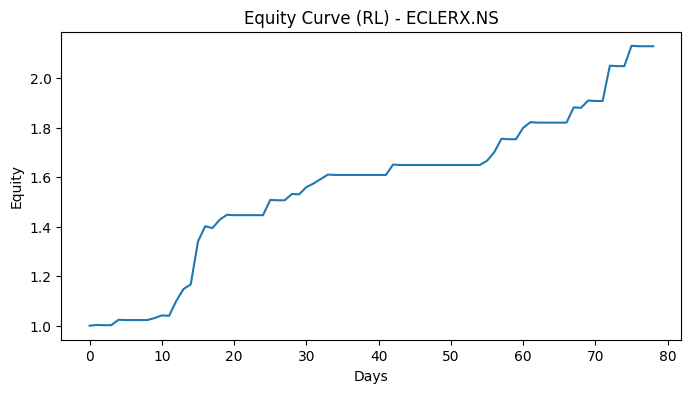

In [62]:
from sklearn.preprocessing import StandardScaler

def evaluate_on_ticker(model, df, cost_bps=COST_BPS, allow_short=bool(ALLOW_SHORT), plot=False):
    feat = make_features(df)
    feat = align_feature_schema(feat, FEATURE_ORDER)
    feat_cols = [c for c in feat.columns if c != 'close']
    cols = [c for c in feat.columns if c != 'close']
    feat_scaled = feat.copy()
    feat_scaled[cols] = GLOBAL_SCALER.transform(feat_scaled[cols])  # <— use the global scaler
    env = SingleStockTradingEnv(feat_scaled, price_col='close', feature_cols=cols, cost_bps=COST_BPS, allow_short=bool(ALLOW_SHORT))

    obs, info = env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(int(action))
        done = terminated or truncated

    rets = np.array(env.returns_hist)
    curve = np.array(env.equity_curve)
    stats = {
        "CumulativeReturn": float(curve[-1]-1.0) if len(curve) else 0.0,
        "CAGR": cagr(rets),
        "Sharpe": sharpe_ratio(rets),
        "Sortino": sortino_ratio(rets),
        "MaxDrawdown": max_drawdown(curve),
        "HitRate": hit_rate(rets),
        "Turnover": turnover(env.positions_hist)
    }
    if plot and len(curve):
        plt.plot(curve); plt.title("Equity Curve"); plt.xlabel("Days"); plt.ylabel("Equity"); plt.show()
    return stats, curve

# Evaluate RL on the last 10 weeks of each ticker
rl_rows, rl_curves = [], {}
for t in TICKERS:
    try:
        full = download_ohlcv(t, start=START)
        train_df, test_df = split_train_test(full, test_weeks=TEST_WEEKS)
        if test_df is None:
            print(f"Skip {t}: not enough test history")
            continue
        stats, curve = evaluate_on_ticker(model, test_df, plot=False)
        rl_rows.append({"Ticker": t, **stats})
        rl_curves[t] = curve
        print(t, stats)
    except Exception as e:
        print(f"Skip {t}: {e}")

rl_df = pd.DataFrame(rl_rows)
if len(rl_df):
    display(rl_df.sort_values("CumulativeReturn", ascending=False))
    # Plot best ticker curve
    best_t = rl_df.sort_values("CumulativeReturn", ascending=False).iloc[0]["Ticker"]
    plt.plot(rl_curves[best_t]); plt.title(f"Equity Curve (RL) - {best_t}"); plt.xlabel("Days"); plt.ylabel("Equity"); plt.show()
else:
    print("No RL results (check data/connectivity).")


## baseline_lstm

In [63]:
import torch.nn as nn
import torch.optim as optim

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden=64, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, num_layers=layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

from sklearn.preprocessing import StandardScaler

def build_sequences(feat_df, seq_len=20):
    ret_next = feat_df['close'].pct_change().shift(-1)
    X = feat_df.drop(columns=['close']).values
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    seqs, ys = [], []
    for i in range(len(feat_df) - seq_len - 1):
        seqs.append(X[i:i+seq_len])
        ys.append(1.0 if ret_next.iloc[i+seq_len] > 0 else 0.0)
    X = np.array(seqs, dtype=np.float32)
    y = np.array(ys, dtype=np.float32).reshape(-1,1)
    return X, y

def train_lstm(X, y, epochs=20, lr=1e-3, batch=64):
    model = LSTMModel(X.shape[-1]).to(DEVICE)
    loss_fn = nn.BCEWithLogitsLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    ds = torch.utils.data.TensorDataset(torch.tensor(X), torch.tensor(y))
    dl = torch.utils.data.DataLoader(ds, batch_size=batch, shuffle=True)
    model.train()
    for ep in range(epochs):
        total = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()
            total += loss.item() * xb.size(0)
        if (ep+1) % 5 == 0:
            print(f"Epoch {ep+1}/{epochs} loss={total/len(ds):.4f}")
    return model

def backtest_from_probs(feat_df, probs, cost_bps=COST_BPS):
    pos = (probs > 0.5).astype(float)
    ret = feat_df['close'].pct_change().shift(-1).fillna(0.0).values
    pos = np.concatenate([[0.0], pos[:-1]])
    cost = (cost_bps/10000.0) * np.abs(np.diff(np.concatenate([[0.0], pos])))
    pnl = pos * ret - cost
    curve = (1 + pnl).cumprod()
    return pnl, curve, pos

# BEFORE the loop:
lstm_rows = []
lstm_curves = {}      # NEW: store LSTM equity curves per ticker
lstm_bh_curves = {}   # NEW: store Buy & Hold curves per ticker (optional)

# Train + evaluate LSTM per ticker
for t in TICKERS:
    try:
        df = download_ohlcv(t, start=START)
        train_df, test_df = split_train_test(df, test_weeks=TEST_WEEKS)
        if train_df is None or test_df is None:
            print(f"Skip {t}: not enough history for LSTM")
            continue
        ftr = align_feature_schema(make_features(train_df), FEATURE_ORDER)
        fte = align_feature_schema(make_features(test_df), FEATURE_ORDER)

        Xtr, ytr = build_sequences(ftr, seq_len=20)
        if len(Xtr)==0:
            print(f"Skip {t}: no training sequences")
            continue
        lstm = train_lstm(Xtr, ytr, epochs=20)

        Xte, yte = build_sequences(fte, seq_len=20)
        if len(Xte)==0:
            print(f"Skip {t}: no test sequences")
            continue
        with torch.no_grad():
            logits = lstm(torch.tensor(Xte).to(DEVICE)).cpu().numpy().ravel()
            probs = 1/(1+np.exp(-logits))
        pnl, curve, pos = backtest_from_probs(fte.iloc[-len(probs):], probs)

        # --- SAVE CURVES (equity vs day) ---
        lstm_curves[t] = curve                                   # NEW
        bh_prices = fte['close'].iloc[-len(curve):].to_numpy()   # NEW
        lstm_bh_curves[t] = bh_prices / bh_prices[0]             # NEW

        lstm_rows.append({
            "Ticker": t,
            "CumulativeReturn": float(curve[-1]-1.0),
            "CAGR": cagr(pnl),
            "Sharpe": sharpe_ratio(pnl),
            "Sortino": sortino_ratio(pnl),
            "MaxDrawdown": max_drawdown(curve),
            "HitRate": hit_rate(pnl),
            "Turnover": turnover(pos)
        })
    except Exception as e:
        print(f"Skip {t}: {e}")

lstm_df = pd.DataFrame(lstm_rows)
if len(lstm_df):
    display(lstm_df.sort_values("CumulativeReturn", ascending=False))
else:
    print("No LSTM results.")



[*********************100%***********************]  1 of 1 completed


Epoch 5/20 loss=0.6845
Epoch 10/20 loss=0.6585
Epoch 15/20 loss=0.6282
Epoch 20/20 loss=0.5825


[*********************100%***********************]  1 of 1 completed


Epoch 5/20 loss=0.6822
Epoch 10/20 loss=0.6561
Epoch 15/20 loss=0.6206
Epoch 20/20 loss=0.5677


[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['LICINDIA.NS']: YFTzMissingError('possibly delisted; no timezone found')


Skip LICIndia.NS: not enough history for LSTM


[*********************100%***********************]  1 of 1 completed


Epoch 5/20 loss=0.6681
Epoch 10/20 loss=0.6512
Epoch 15/20 loss=0.6337
Epoch 20/20 loss=0.6140


,Ticker,CumulativeReturn,CAGR,Sharpe,Sortino,MaxDrawdown,HitRate,Turnover
94,ECLERX.NS,0.223363,1.365731,5.767829,16.011818,-0.033200,0.288136,0.189655
95,JIOFIN.NS,0.180065,1.028257,5.702158,16.903971,-0.033162,0.203390,0.137931
15,BOSCHLTD.NS,0.162898,0.905197,5.748475,19.239536,-0.031377,0.271186,0.224138
81,INDIGO.NS,0.136560,0.727610,4.898802,12.007564,-0.061753,0.288136,0.258621
33,HEROMOTOCO.NS,0.111626,0.571440,3.443169,9.066711,-0.041998,0.271186,0.344828
...,...,...,...,...,...,...,...,...
51,NTPC.NS,-0.121835,-0.425880,-4.215037,-5.346695,-0.121835,0.220339,0.344828
6,AXISBANK.NS,-0.123258,-0.429843,-3.086387,-3.353924,-0.130491,0.152542,0.293103
12,BHEL.NS,-0.126596,-0.439056,-2.394591,-3.121039,-0.155913,0.135593,0.362069
68,TATAMOTORS.NS,-0.130120,-0.448659,-2.250046,-3.012565,-0.177853,0.338983,0.155172


## Compare RL vs LSTM

,Ticker,CumulativeReturn_RL,CAGR_RL,Sharpe_RL,Sortino_RL,MaxDrawdown_RL,HitRate_RL,Turnover_RL,CumulativeReturn_LSTM,CAGR_LSTM,Sharpe_LSTM,Sortino_LSTM,MaxDrawdown_LSTM,HitRate_LSTM,Turnover_LSTM
0,ABB.NS,0.196146,0.783620,6.852268,175.319680,-0.001000,0.115385,0.179487,-0.111589,-0.396717,-2.265939,-3.382262,-0.146035,0.271186,0.189655
1,ADANIENT.NS,0.564003,3.241666,15.672109,563.673534,-0.001000,0.346154,0.346154,-0.180266,-0.572161,-2.821136,-4.100375,-0.216937,0.220339,0.258621
2,ADANIPOWER.NS,0.713831,4.700286,21.055579,364.227982,-0.006741,0.435897,0.435897,0.005028,0.021654,0.210212,0.465960,-0.063085,0.220339,0.362069
3,AMBUJACEM.NS,0.414465,2.065694,15.206156,103.694651,-0.010055,0.461538,0.487179,0.058039,0.272482,1.752191,2.728860,-0.049711,0.322034,0.224138
4,APOLLOHOSP.NS,0.169994,0.660680,5.937307,147.916111,-0.001000,0.089744,0.179487,0.030523,0.137029,0.965051,1.853758,-0.067875,0.254237,0.172414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,IRCTC.NS,0.341724,1.584941,11.888312,110.857821,-0.006765,0.461538,0.410256,-0.021362,-0.088103,-0.871664,-1.340633,-0.053059,0.254237,0.155172
92,IRFC.NS,0.558089,3.190068,15.143982,189.607357,-0.008988,0.410256,0.461538,-0.026182,-0.107133,-0.525731,-0.779402,-0.099415,0.322034,0.103448
93,LODHA.NS,0.659298,4.134817,21.815755,519.955725,-0.003834,0.423077,0.461538,0.020354,0.089873,0.627859,1.052201,-0.052764,0.254237,0.137931
94,ECLERX.NS,1.127934,10.469834,31.853407,959.817538,-0.005573,0.346154,0.333333,0.223363,1.365731,5.767829,16.011818,-0.033200,0.288136,0.189655


,Metric,RL,LSTM
0,CumulativeReturn,0.432681,-0.015312
1,CAGR,2.411622,-0.032824
2,Sharpe,15.063866,-0.272679
3,Sortino,247.053136,0.218754
4,MaxDrawdown,-0.005061,-0.076014
5,HitRate,0.373798,0.248941
6,Turnover,0.419872,0.258621


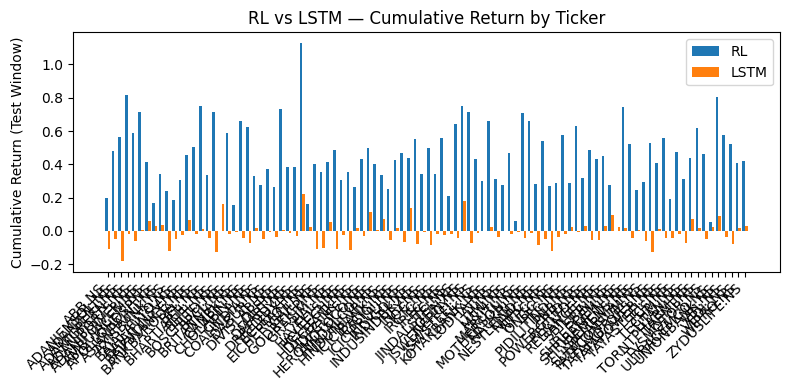

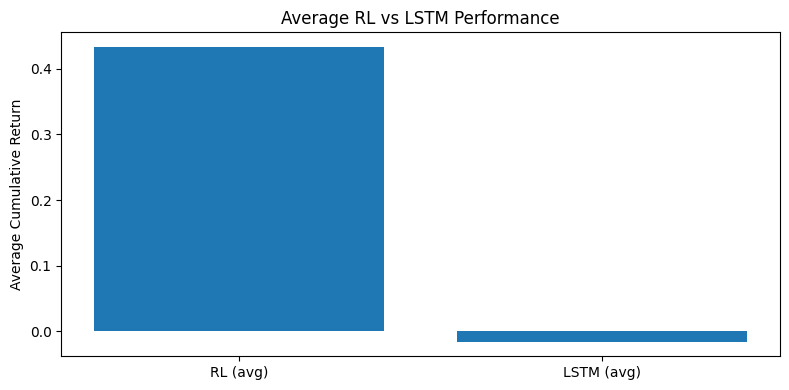

In [67]:
if 'rl_df' in globals() and len(rl_df) and 'lstm_df' in globals() and len(lstm_df):
    merged = pd.merge(rl_df, lstm_df, on="Ticker", suffixes=("_RL","_LSTM"))
    display(merged)
    metrics = ["CumulativeReturn","CAGR","Sharpe","Sortino","MaxDrawdown","HitRate","Turnover"]
    avg = pd.DataFrame({"Metric": metrics,
                        "RL": [merged[f"{m}_RL"].mean() for m in metrics],
                        "LSTM": [merged[f"{m}_LSTM"].mean() for m in metrics]})
    display(avg)
else:
    print("Run both RL and LSTM sections first.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes you already have:
# rl_df   -> from RL eval, with columns ["Ticker", "CumulativeReturn", ...]
# lstm_df -> from LSTM eval, with columns ["Ticker", "CumulativeReturn", ...]

# Merge on common tickers
comp = pd.merge(
    rl_df[['Ticker','CumulativeReturn']].rename(columns={'CumulativeReturn':'RL_Return'}),
    lstm_df[['Ticker','CumulativeReturn']].rename(columns={'CumulativeReturn':'LSTM_Return'}),
    on='Ticker',
    how='inner'
).sort_values('Ticker')

# Grouped bar chart
x = np.arange(len(comp))
width = 0.4

plt.figure()
plt.bar(x - width/2, comp['RL_Return'].values, width, label='RL')
plt.bar(x + width/2, comp['LSTM_Return'].values, width, label='LSTM')
plt.xticks(x, comp['Ticker'].tolist(), rotation=45, ha='right')
plt.ylabel('Cumulative Return (Test Window)')
plt.title('RL vs LSTM — Cumulative Return by Ticker')
plt.legend()
plt.tight_layout()
plt.savefig("RL vs LSTM.png")
plt.show()

# (Optional) Summary bar: mean returns across tickers
plt.figure()
means = [comp['RL_Return'].mean(), comp['LSTM_Return'].mean()]
labels = ['RL (avg)', 'LSTM (avg)']
plt.bar(np.arange(len(means)), means)
plt.xticks(np.arange(len(means)), labels)
plt.ylabel('Average Cumulative Return')
plt.title('Average RL vs LSTM Performance')
plt.savefig("RL vs LSTM_Average CR.png")
plt.tight_layout()
plt.show()



In [48]:
rl_df

,Ticker,CumulativeReturn,CAGR,Sharpe,Sortino,MaxDrawdown,HitRate,Turnover
0,ABB.NS,0.336555,1.552903,12.815148,251.573080,-0.001000,0.346154,0.397436
1,ADANIENT.NS,0.573430,3.324823,16.077288,296.158954,-0.006630,0.397436,0.397436
2,ADANIPOWER.NS,0.697344,4.525017,20.178870,271.695153,-0.007267,0.397436,0.397436
3,AMBUJACEM.NS,0.431866,2.189224,16.419137,144.750957,-0.011285,0.461538,0.461538
4,APOLLOHOSP.NS,0.351849,1.648491,13.118767,233.728119,-0.001000,0.320513,0.564103
...,...,...,...,...,...,...,...,...
91,IRCTC.NS,0.314666,1.420277,10.660201,100.954288,-0.007758,0.410256,0.487179
92,IRFC.NS,0.557797,3.187530,15.130729,253.279355,-0.006134,0.358974,0.487179
93,LODHA.NS,0.657159,4.113465,21.615308,311.584569,-0.008254,0.448718,0.512821
94,ECLERX.NS,1.134614,10.586574,32.196978,831.723100,-0.005573,0.397436,0.461538


In [49]:
lstm_df

,Ticker,CumulativeReturn,CAGR,Sharpe,Sortino,MaxDrawdown,HitRate,Turnover
0,ABB.NS,-0.119612,-0.419648,-2.645487,-3.642325,-0.124870,0.169492,0.172414
1,ADANIENT.NS,-0.070372,-0.267779,-1.818570,-2.704311,-0.077816,0.203390,0.206897
2,ADANIPOWER.NS,0.060467,0.285000,1.622026,4.256429,-0.045349,0.271186,0.327586
3,AMBUJACEM.NS,0.032967,0.148590,1.079126,1.806047,-0.054128,0.305085,0.327586
4,APOLLOHOSP.NS,0.001964,0.008416,0.131327,0.235180,-0.048979,0.186441,0.206897
...,...,...,...,...,...,...,...,...
91,IRCTC.NS,-0.046748,-0.184933,-2.108874,-2.875429,-0.066846,0.254237,0.224138
92,IRFC.NS,-0.077694,-0.292096,-1.638454,-2.210787,-0.089303,0.271186,0.172414
93,LODHA.NS,-0.016516,-0.068663,-0.342769,-0.577042,-0.068291,0.203390,0.172414
94,ECLERX.NS,0.220503,1.342200,5.523976,15.330606,-0.033200,0.305085,0.189655


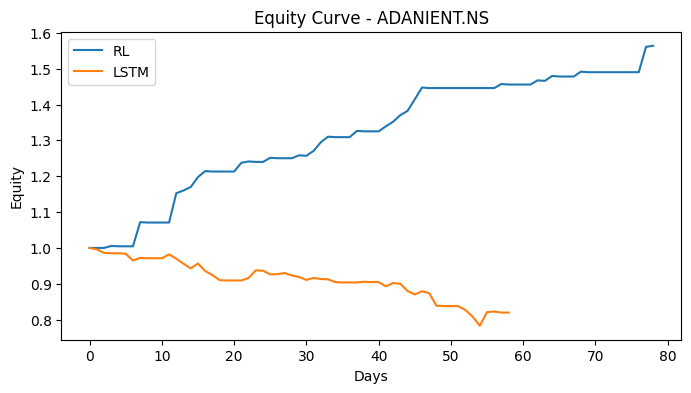

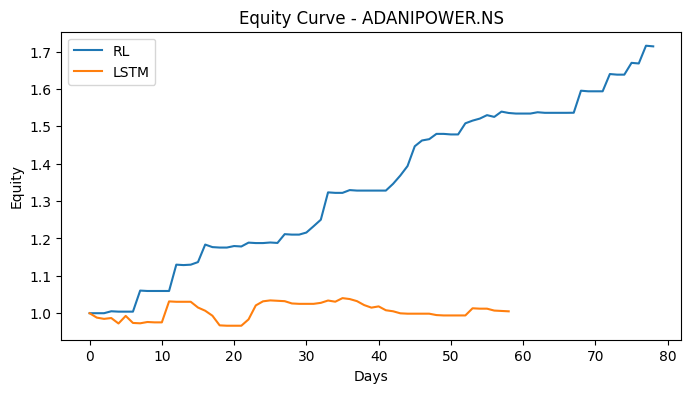

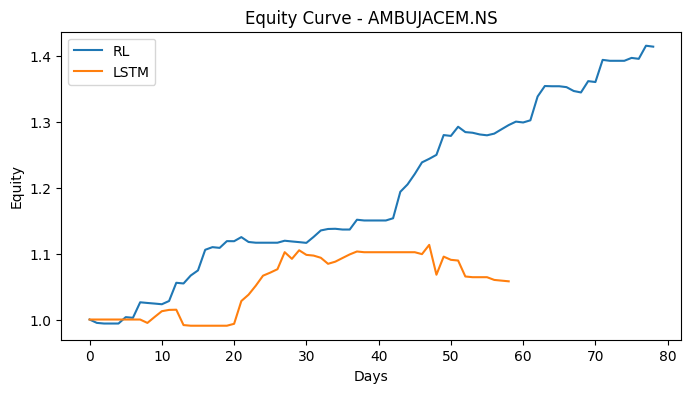

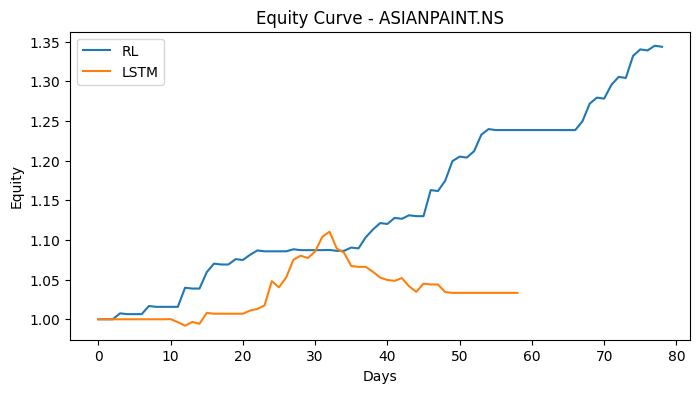

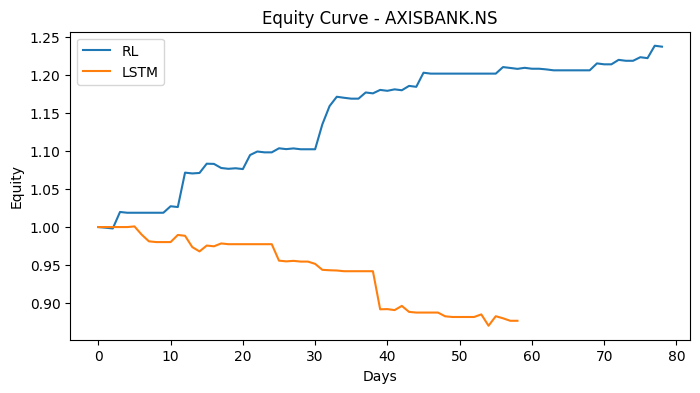

In [70]:
for t in ["ADANIENT.NS", "ADANIPOWER.NS", "AMBUJACEM.NS", "ASIANPAINT.NS", "AXISBANK.NS"]:
    plt.plot(rl_curves[t], label = 'RL')
    plt.plot(lstm_curves[t], label = 'LSTM') 
    plt.legend()
    plt.title(f"Equity Curve - {t}")
    plt.xlabel("Days")
    plt.ylabel("Equity")
    plt.show()

In [71]:
comp.to_csv('RL VS LSTM Return.csv', index = False)
rl_df.to_csv('RL_results.csv', index = False)
lstm_df.to_csv('LSTM_results.csv', index = False)